# QFT and AQFT based adders (QFTDraperAdder)
**Author:** Arthur Wunder Damásio  
**Subject:** Quantum Information Theory  
**Professor:** José Roberto Castilho Piqueira 

**Date:** April 8, 2026

---

## Abstract
This notebook focuses on a implementation of the QFT-based adder proposed by Thomas G. Draper [\[1\]](https://arxiv.org/pdf/quant-ph/0008033). This implementation will be done using QFTDraperAdder as reference.

## Quantum Fourier Transform Based Adder (QFT-based Adder)



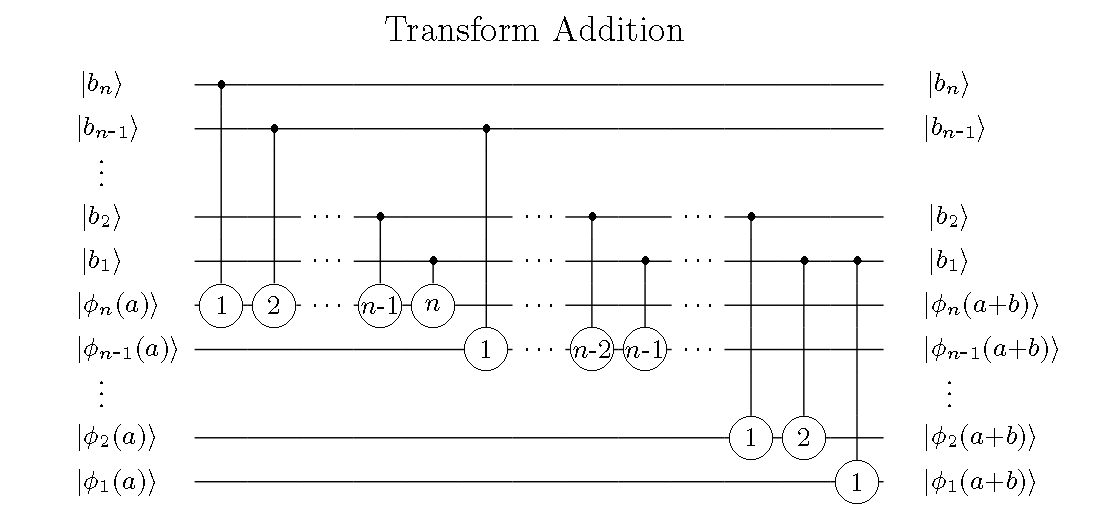

In [1]:
from qft_aqft import AQFT, QFT
import numpy as np
from qiskit.circuit.library import HGate
from qiskit.circuit import Gate
from qiskit.quantum_info import *
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

In [2]:
def QFTDraperAdder(n):
    qr_a = QuantumRegister(n, name="a")
    qr_b = QuantumRegister(n, name="b")
    qc = QuantumCircuit(qr_a, qr_b, name="MyQFTDraper")
    
    # 1. QFT without swaps!
    qc.append(QFT(n, do_swaps=False), qr_b[:])
    
    for j in range(n):
        for k in range(n - j):
            lam = np.pi / (2 ** k)
            qc.cp(lam, qr_a[j], qr_b[j + k])
            
    # 3. Inverse QFT without swaps
    qc.append(QFT(n, do_swaps=False).inverse(), qr_b[:])
    
    return qc

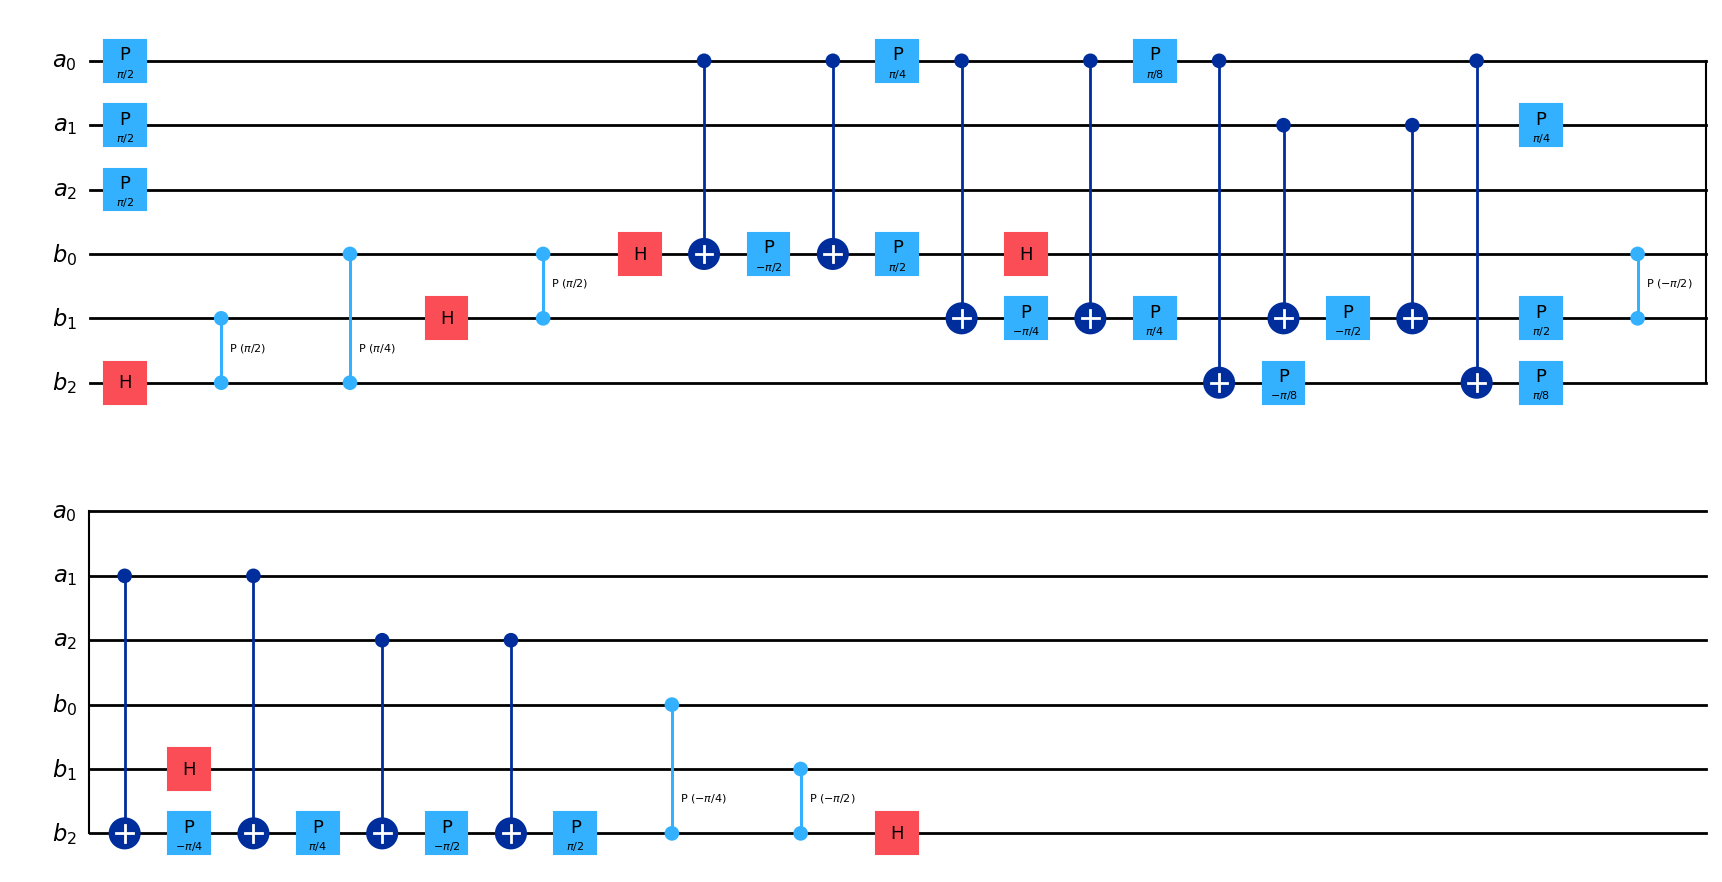

In [3]:
n_qubits = 3
somador = QFTDraperAdder(n_qubits)

somador.decompose().draw('mpl')

Counts: {'101': 1000}


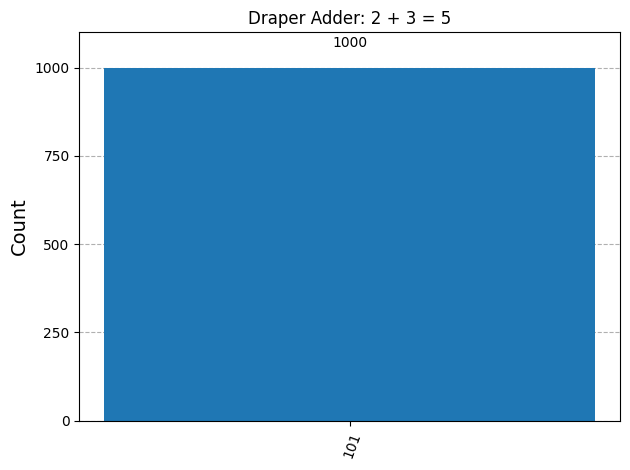

In [4]:
n = 3
reg_A = QuantumRegister(n, name='A')
reg_B = QuantumRegister(n, name='B')
medida = ClassicalRegister(n, name='resultado')
qc_teste = QuantumCircuit(reg_A, reg_B, medida)

# Initialization for LSB convention
# A = 2 (Binary 010)
qc_teste.x(reg_A[1]) 

# B = 3 (Binary 011 -> 1 + 2)
qc_teste.x(reg_B[0])
qc_teste.x(reg_B[1])

# Append the LSB-compatible Draper Adder
qc_teste.append(QFTDraperAdder(n), reg_A[:] + reg_B[:])

# Measure
qc_teste.measure(reg_B, medida)

# Run simulation
simulador = AerSimulator()
circuito_compilado = transpile(qc_teste, simulador)
resultado = simulador.run(circuito_compilado, shots=1000).result()
contagens = resultado.get_counts()

# Print and plot
print(f"Counts: {contagens}")
plot_histogram(contagens, title="Draper Adder: 2 + 3 = 5")

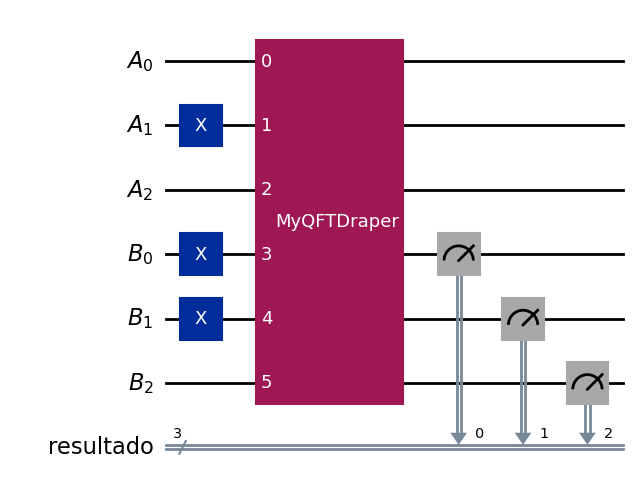

In [5]:
qc_teste.draw("mpl")

In [ ]:
def AQFTDraperAdder(n):
    reg_a = QuantumRegister(n, name='A')
    reg_b = QuantumRegister(n, name='B')
    qc = QuantumCircuit(reg_a, reg_b, name="MyAQFTDraper")
    
    qc.append(AQFT(n, do_swap=False), reg_b[:])
    
    for j in range(n):
        for k in range(n - j):
            lam = np.pi / (2 ** k)
            qc.cp(lam, reg_a[j], reg_b[j + k])
            
    qc.append(AQFT(n, do_swap=False).inverse(), reg_b[:])
    
    return qc


Counts: {'101': 1000}


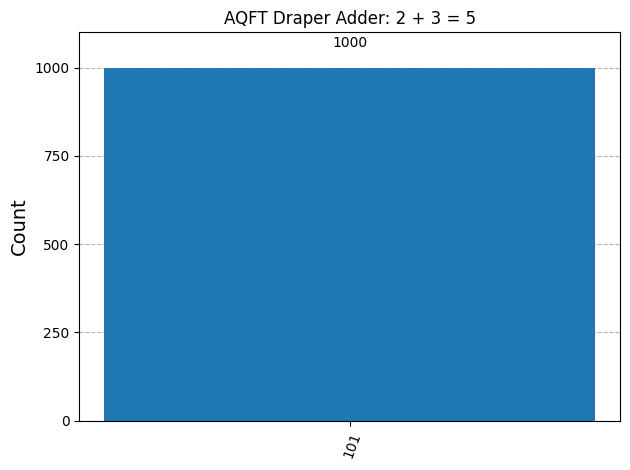

In [ ]:
n_aqft = 3
reg_A_aqft = QuantumRegister(n_aqft, name='A')
reg_B_aqft = QuantumRegister(n_aqft, name='B')
medida_aqft = ClassicalRegister(n_aqft, name='resultado')
qc_teste_aqft = QuantumCircuit(reg_A_aqft, reg_B_aqft, medida_aqft)

qc_teste_aqft.x(reg_A_aqft[1]) 

qc_teste_aqft.x(reg_B_aqft[0])
qc_teste_aqft.x(reg_B_aqft[1])

qc_teste_aqft.append(AQFTDraperAdder(n_aqft), reg_A_aqft[:] + reg_B_aqft[:])

qc_teste_aqft.measure(reg_B_aqft, medida_aqft)

simulador = AerSimulator()
circuito_compilado = transpile(qc_teste_aqft, simulador)
resultado = simulador.run(circuito_compilado, shots=1000).result()
contagens = resultado.get_counts()

print(f"Counts: {contagens}")
plot_histogram(contagens, title="AQFT Draper Adder: 2 + 3 = 5")